In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import tools.particle_swarm_optimization as pso
import tools.particle_swarm_optimization_plot as pso_plt
import tools.peristimulus_time_histogram as psth

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



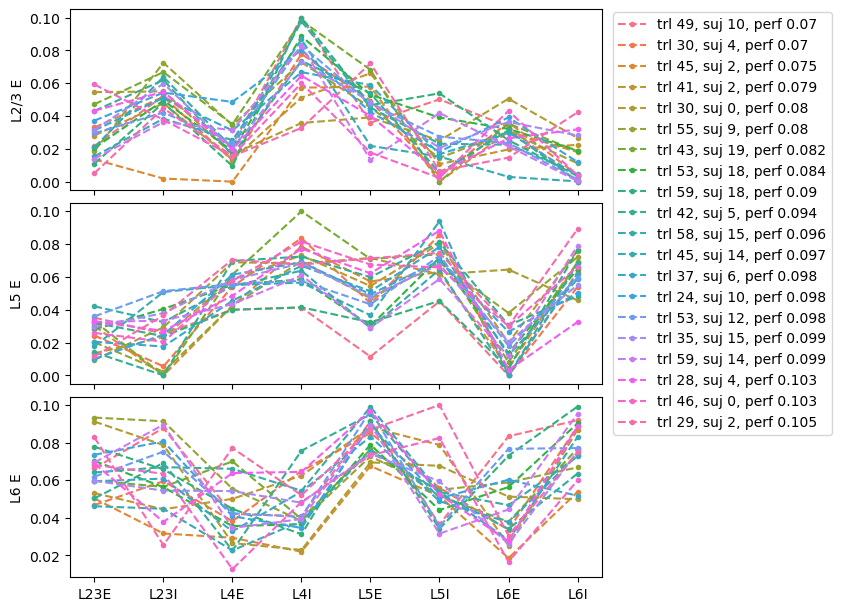

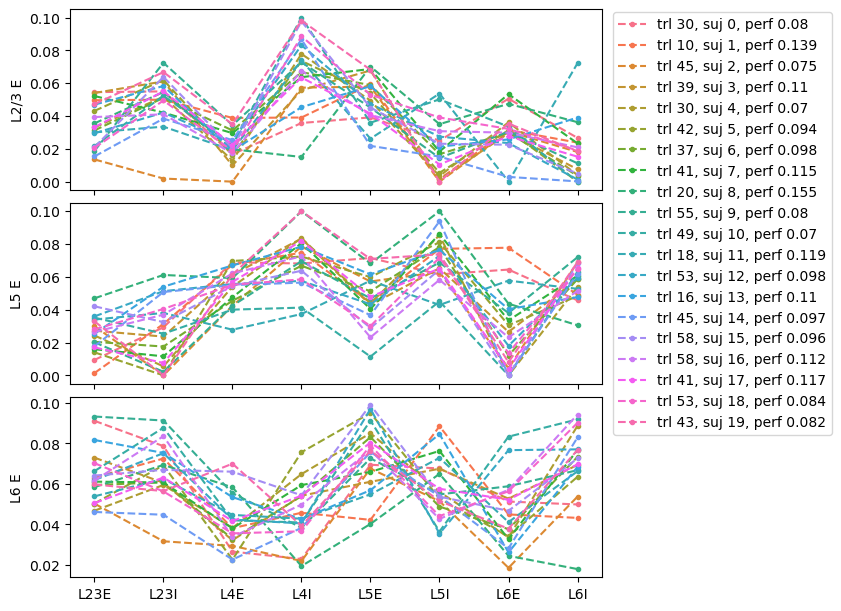

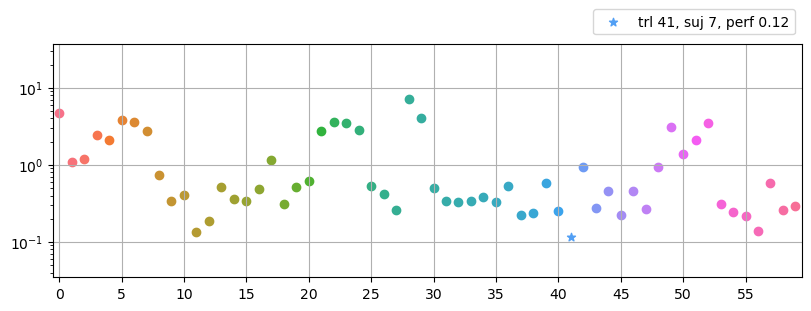

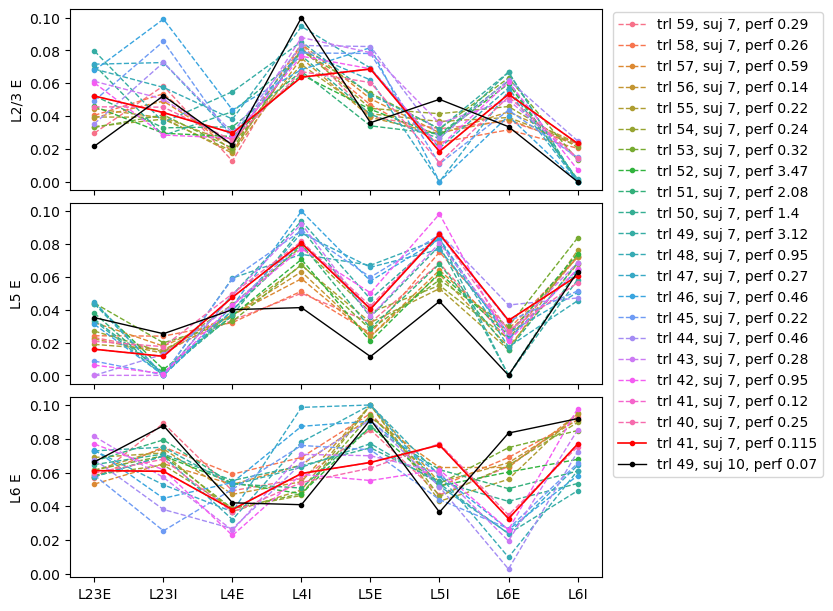

In [97]:
# plot params PSO
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')

suj = 7
pso.plot_best_params(folder_path, 'all')
pso.plot_best_params(folder_path, 'sub')

#pso.plot_params(folder_path, 59,-1)
#pso.plot_performance(folder_path, -1, -1, -1)

pso.plot_performance(folder_path, -1, suj, -1)
pso.plot_params(folder_path, -1, suj)

#pso.plot_activity(folder_path, -1, -1, -10)
plt.show()

In [4]:
# Plot best params de 32 parámetros
folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

pso.plot_best_params_32(folder_path, 'all')
pso.plot_best_params_32(folder_path, 'sub')

AttributeError: module 'tools.particle_swarm_optimization' has no attribute 'plot_best_params_32'

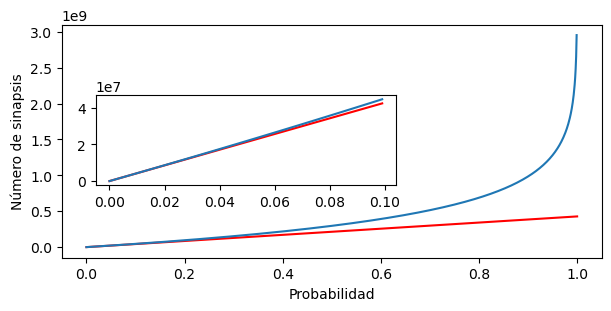

In [195]:
# plot del número de sinapsis
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
prods = np.array([10, 100, 1000, 1000])

ng = 20683
prod = ng*ng
prob = np.linspace(0,1,1000)
rs = np.log(1. - prob) / np.log((prod - 1.) / prod)
ws = prob*prod

fig, ax = plt.subplots(1, layout='constrained', figsize=(6,3), sharex=True,sharey=True)

ax.plot(prob, ws,'r')
ax.plot(prob, rs)

left, bottom, width, height = 0.15, 0.4, 0.5, 0.3
ax2 = fig.add_axes([left, bottom, width, height])
ax2.plot(prob[:100], ws[:100],'r')
ax2.plot(prob[:100], rs[:100])

ax.set_xlabel('Probabilidad')
ax.set_ylabel('Número de sinapsis')
plt.show()



Text(0.5, 0.98, 'Cantidad de sinapsis del promedio de los 20 mejores')

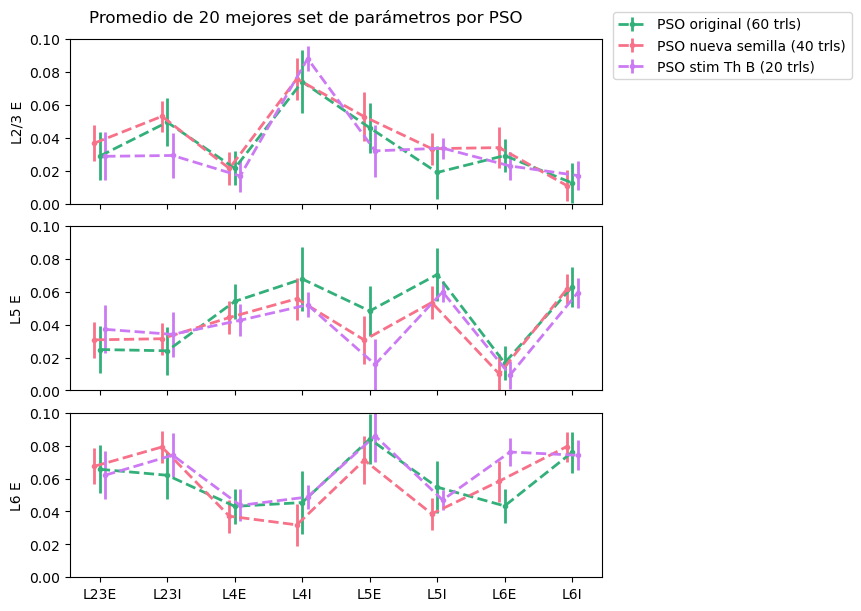

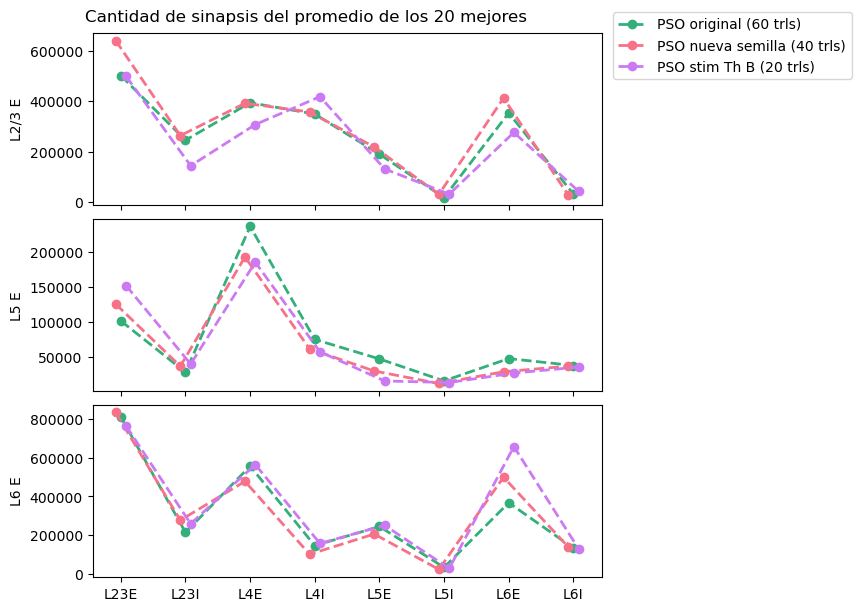

In [4]:
#print figura proimedios y número de sinapsis
folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

params = range(0, 8*3)
df = pd.read_csv(os.path.join(folder_path, 'test.csv'), header=None, names=params)
Df = df.values

clrs = sns.color_palette('husl', n_colors=5)  # a list of RGB tuples
labels =['PSO nueva semilla (40 trls)','PSO original (60 trls)','PSO stim Th B (20 trls)']

fig, ax = plt.subplots(3, layout='constrained', figsize=(6,6), sharex=True,sharey=True)
for i in [2,0,4]:
    l = (i-2)/25
    ax[0].errorbar(np.linspace(0+l,7+l,8), Df[i][0:8], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i])
    ax[1].errorbar(np.linspace(0+l,7+l,8), Df[i][8:16], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i])
    ax[2].errorbar(np.linspace(0+l,7+l,8), Df[i][16:24], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i], label=labels[int(i/2)])
ax[0].set_ylabel('L2/3 E')
ax[1].set_ylabel('L5 E')
ax[2].set_ylabel('L6 E')
ax[2].set_xticks(range(8),['L23E','L23I','L4E','L4I','L5E','L5I','L6E','L6I'])
ax[2].set_ylim([0, 0.1])
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
    fancybox=True, shadow=False, ncol=1)
fig.suptitle('Promedio de 20 mejores set de parámetros por PSO')


popsize1 = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
popsize2 = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
prod = np.outer(popsize1, popsize2)

fig, ax = plt.subplots(3, layout='constrained', figsize=(6,6), sharex=True)
for i in [2,0,4]:
    l = (i-2)/25
    new_conn_probs = pso.new_conn_probs(Df[i])
    num_synapses = np.log(1. - new_conn_probs) / np.log((prod - 1.) / prod)
    ns = np.round((num_synapses *0.2 *0.2)).astype(int)

    ax[0].plot(np.linspace(0+l,7+l,8), ns[:,0], 'o--', lw=2, c=clrs[i])
    ax[1].plot(np.linspace(0+l,7+l,8), ns[:,4], 'o--', lw=2, c=clrs[i])
    ax[2].plot(np.linspace(0+l,7+l,8), ns[:,6], 'o--', lw=2, c=clrs[i], 
        label=labels[int(i/2)])
ax[0].set_ylabel('L2/3 E')
ax[1].set_ylabel('L5 E')
ax[2].set_ylabel('L6 E')
ax[2].set_xticks(range(8),['L23E','L23I','L4E','L4I','L5E','L5I','L6E','L6I'])
#ax[2].set_ylim([0, 0.1])
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
    fancybox=True, shadow=False, ncol=1)
fig.suptitle('Cantidad de sinapsis del promedio de los 20 mejores')



[ 9.         17.          0.62959381  0.7794971   0.75499678  0.68246293
  0.05696647]


ValueError: 'c' argument has 1250 elements, which is inconsistent with 'x' and 'y' with size 400.

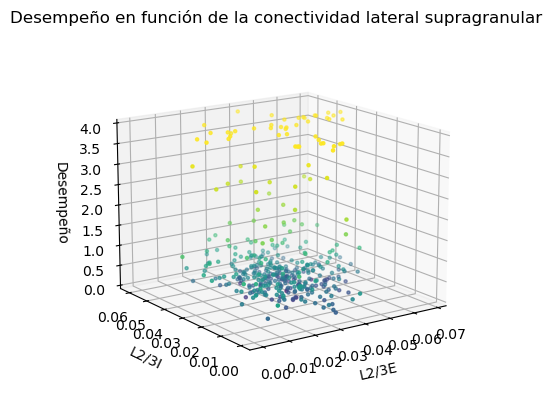

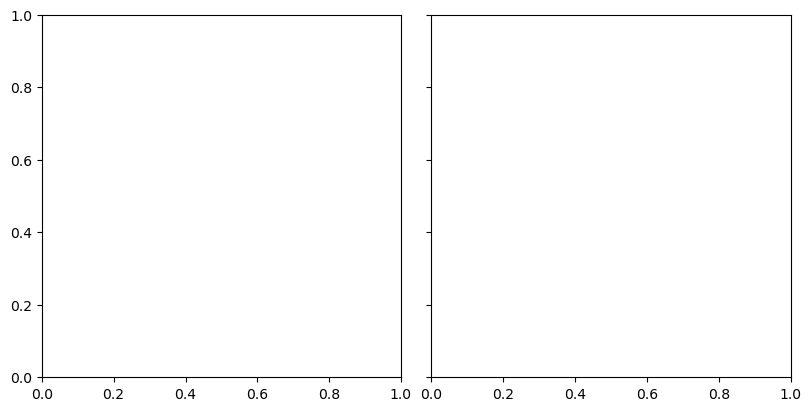

In [119]:
# plot params 2D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

# add columns names
cols = np.array(['trials', 'subjects'])
params = range(8*3)
names = np.concatenate((cols, params), axis=None)
df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)

cols = np.array(['trials', 'subjects'])
params = range(5)
names = np.concatenate((cols, params), axis=None)
df2 = pd.read_csv(os.path.join(folder_path, 'results.csv'), header=None, names=names)
best = df2.sort_values('4').values
print(best[0])
X = df['0'].values
Y = df['1'].values
Z = df2['4'].values
Z[Z>4]=4



fig = plt.figure(layout='constrained', figsize=(8,4))
ax = fig.add_subplot(projection='3d') #
ax.scatter(X, Y, Z, marker='.', c=np.log(Z))
ax.set_zlim(0,4)
# Set the azimuth and elevation angles
ax.view_init(azim=235, elev=15)
ax.set_xlabel('L2/3E')
ax.set_ylabel('L2/3I')
ax.set_zlabel('Desempeño')
fig.suptitle('Desempeño en función de la conectividad lateral supragranular')


clrs = sns.color_palette('husl', n_colors=25)
fig, ax = plt.subplots(1,2, layout='constrained', figsize=(8,4), sharey=True)
ax[0].scatter(X, Y,  marker='.', c=clrs*50)
ax[0].scatter(X[:25], Y[:25],  marker='o', c=clrs)
ax[0].set_ylabel('L2/3 I')
ax[0].set_xlabel('L2/3 E')
lin = [0,0.025,0.05,0.075,0.1]
ax[0].set_xticks(lin, lin)
ax[0].set_yticks(lin, lin)

ax[1].scatter(X, Y,  marker='.', c=np.log(Z))
ax[1].set_xlabel('L2/3 E')
ax[1].set_xticks(lin, lin)

ax[0].grid(visible=True)
ax[1].grid(visible=True)
fig.suptitle('Probabilidad de conexión lateral supragranular desde L2/3E')
plt.show()


ee, ei = [], []
fig, ax = plt.subplots(1, layout='constrained', figsize=(6,6), sharey=True)
for i, suj in enumerate(best):
    suj_suj = df[(df['trials']==suj[0]) & (df['subjects']==suj[1])].values[0]
    ee.append(suj_suj[2])
    ei.append(suj_suj[3])
    ax.scatter(suj_suj[2], suj_suj[3], marker='o', s=100, c=clrs[i],
        label='trl '+str(int(suj[0]))+
            ', suj '+str(int(suj[1]))+
            ', perf '+str(round(suj[6],3)))
    if i == 24:
        break

# Create linear regression object
regr = LinearRegression()

ee = np.array(ee)
ei = np.array(ei)
regr.fit(ee.reshape(25,1), ei.reshape(25,1))
eiy = regr.predict(np.array([[-0.1],[0.1]]))


ax.set_ylabel('L2/3 I')
ax.set_xlabel('L2/3 E')
lin = [0,0.025,0.05,0.075,0.1]
ax.set_xticks(lin, lin)
ax.set_yticks(lin, lin)

bottom, top = plt.ylim()  # return the current ylim
a1, a2 = plt.xlim()  # return the current ylim
ax.plot([[-0.1],[0.1]],eiy,'r')

plt.ylim([bottom, top])
plt.xlim([a1, a2])
ax.grid(visible=True)
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
            fancybox=True, shadow=False, ncol=1)
fig.suptitle('Mejores 25 set de parámetros')

# Ahora puedo obtener el coeficiente b_1
print(u'Coeficiente beta1: ', regr.coef_[0])
 
# Podemos predecir usando el modelo
y_pred = regr.predict(ee.reshape(25,1))
 
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print(u'Error cuadrático medio: %.2f' % mean_squared_error(ei.reshape(25,1), y_pred))
print(u'Estadístico R_2: %.2f' % r2_score(ei.reshape(25,1), y_pred))
plt.show()

In [4]:
## intento de merge de las bases de datos

merge_result = False
if merge_result: 
    # Results
    cols = np.array(['trials', 'subjects'])
    params = range(5)
    names = np.concatenate((cols, params), axis=None)

    df0 = pd.read_csv(os.path.join(folder_path, 'results0.csv'), header=None, names=names)
    df1 = pd.read_csv(os.path.join(folder_path, 'results1.csv'), header=None, names=names)
    m = df0.columns.to_list()

    trial = df0['trials'].unique()
    subject = df0['subjects'].unique()

    for j, trl in enumerate(trial):
        for i, suj in enumerate(subject):

            activity = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)

        for i, suj in enumerate(subject):

            activity = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj+10], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)


# Swarm
cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df0 = pd.read_csv(os.path.join(folder_path, 'swarm0.csv'), header=None, names=names)
df1 = pd.read_csv(os.path.join(folder_path, 'swarm1.csv'), header=None, names=names)
m = df0.columns.to_list()

trial = df0['trials'].unique()
subject = df0['subjects'].unique()

for j, trl in enumerate(trial):
    for i, suj in enumerate(subject):

        params = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)

    for i, suj in enumerate(subject):

        params = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj+10], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)


Variance explained by each principal component: [2.24370724e-01 1.91251125e-01 1.48740917e-01 1.21393815e-01
 1.11319585e-01 7.97568904e-02 5.96120628e-02 4.16070609e-02
 2.19478216e-02 1.80523833e-33]
Variance explained by each principal component: 1.0


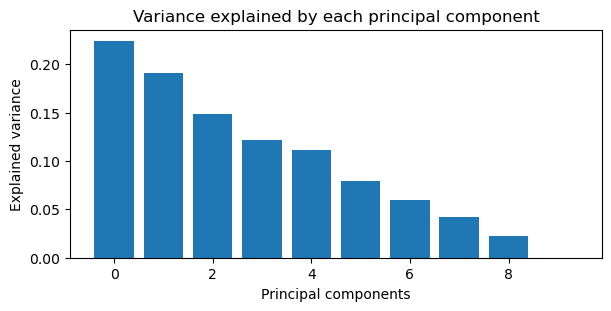

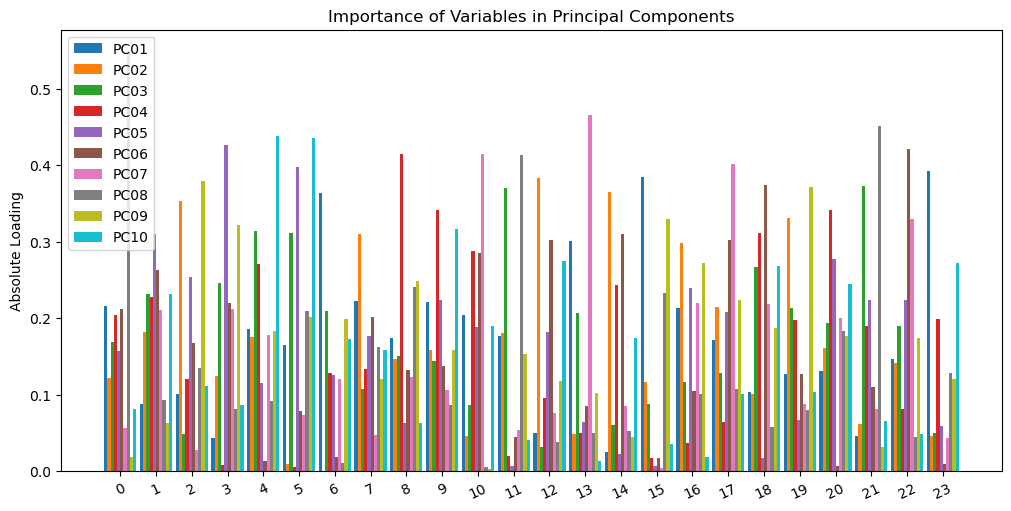

In [137]:
# PCA cluster
# Separate features and group information
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)
pca_metrics = df.columns.to_list()
features = df[pca_metrics[2:]]
group_info = df[['trials', 'subjects']]

# Standardize the data (necessary for a good PCA)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Principal component analysis (PCA)
n_comp = 10
pca = PCA(n_components=n_comp)
principal_components = pca.fit_transform(scaled_features)

comp_names = ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC06', 'PC07', 'PC08', 'PC09','PC10',
            'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19','PC20',
            'PC21', 'PC22', 'PC23', 'PC24']

# Visualize the variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print("Variance explained by each principal component:", explained_variance)
print("Variance explained by each principal component:", np.sum(explained_variance))

# Plot the variance explained by each principal component
fig, ax = plt.subplots(layout='constrained', figsize=(6, 3))
bars = plt.bar(range(len(explained_variance)), explained_variance, align='center')
#plt.xticks(range(len(explained_variance)), comp_names[:len(explained_variance)])
plt.xlabel('Principal components')
plt.ylabel('Explained variance')
plt.title('Variance explained by each principal component')
plt.show()

# A new DataFrame is generated with the PCA principal components
loadings = pca.components_.T
pca_df = pd.DataFrame(loadings, index=features.columns, columns=comp_names[:len(explained_variance)])

# Visualize the importance of the variables in the principal components
fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))
bar_l, x_pos = 0.9/n_comp, np.arange(0,len(pca_metrics[2:]))
for i in range(n_comp):
    plt.bar(x_pos-((bar_l/2)*(n_comp-1))+i*bar_l, np.abs(pca_df[comp_names[i]]), width=bar_l, label=comp_names[i])

plt.xticks(range(len(pca_metrics[2:])), pca_df.index, rotation=25)
plt.ylabel('Absolute Loading')
plt.title('Importance of Variables in Principal Components')
plt.legend()
plt.show()

/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002114232
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002114658
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002115132
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002115522
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002115851
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20241002120212


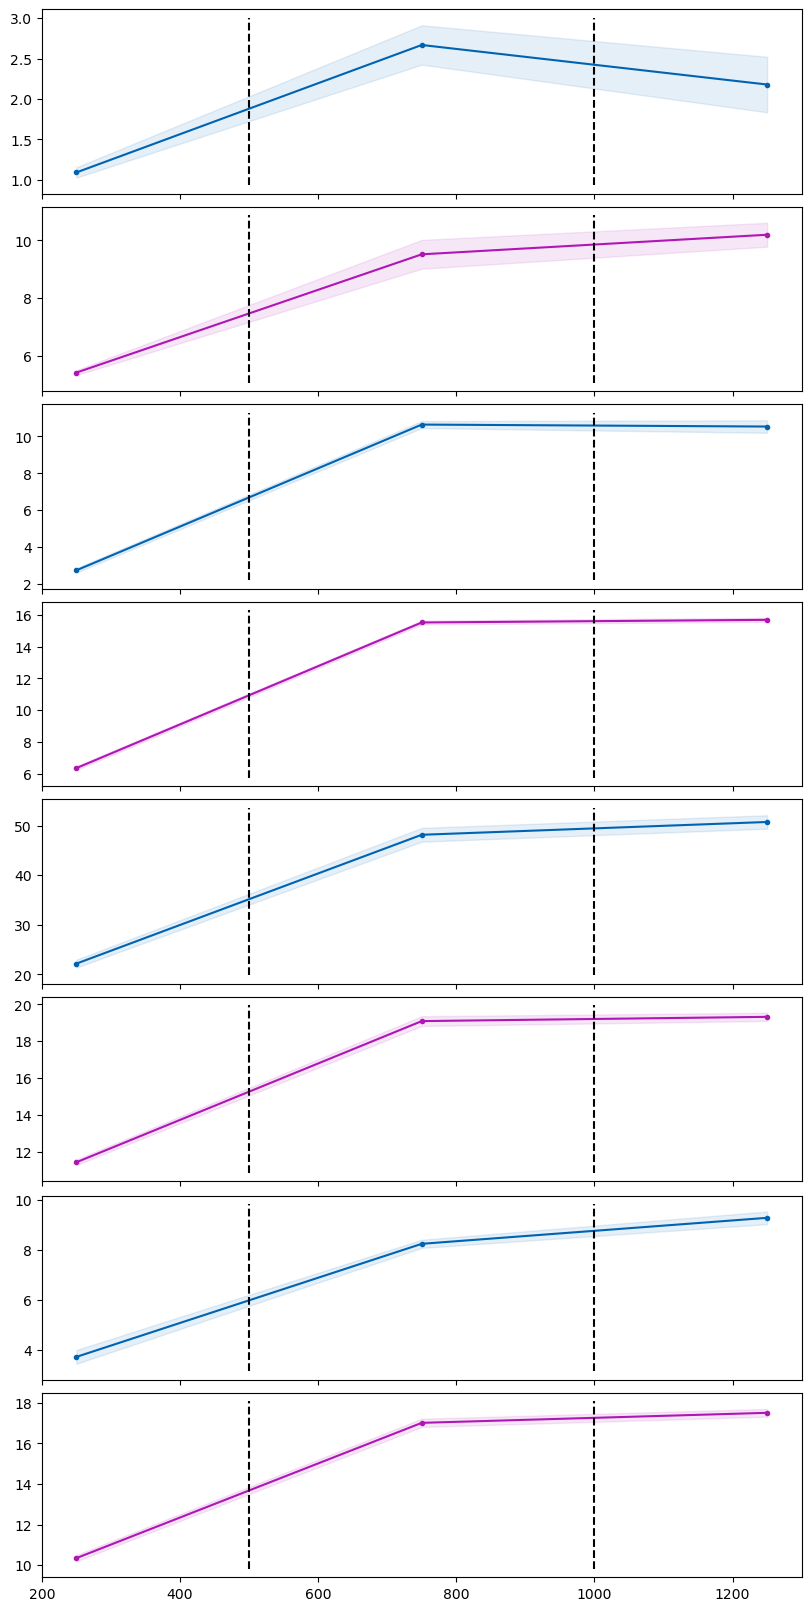

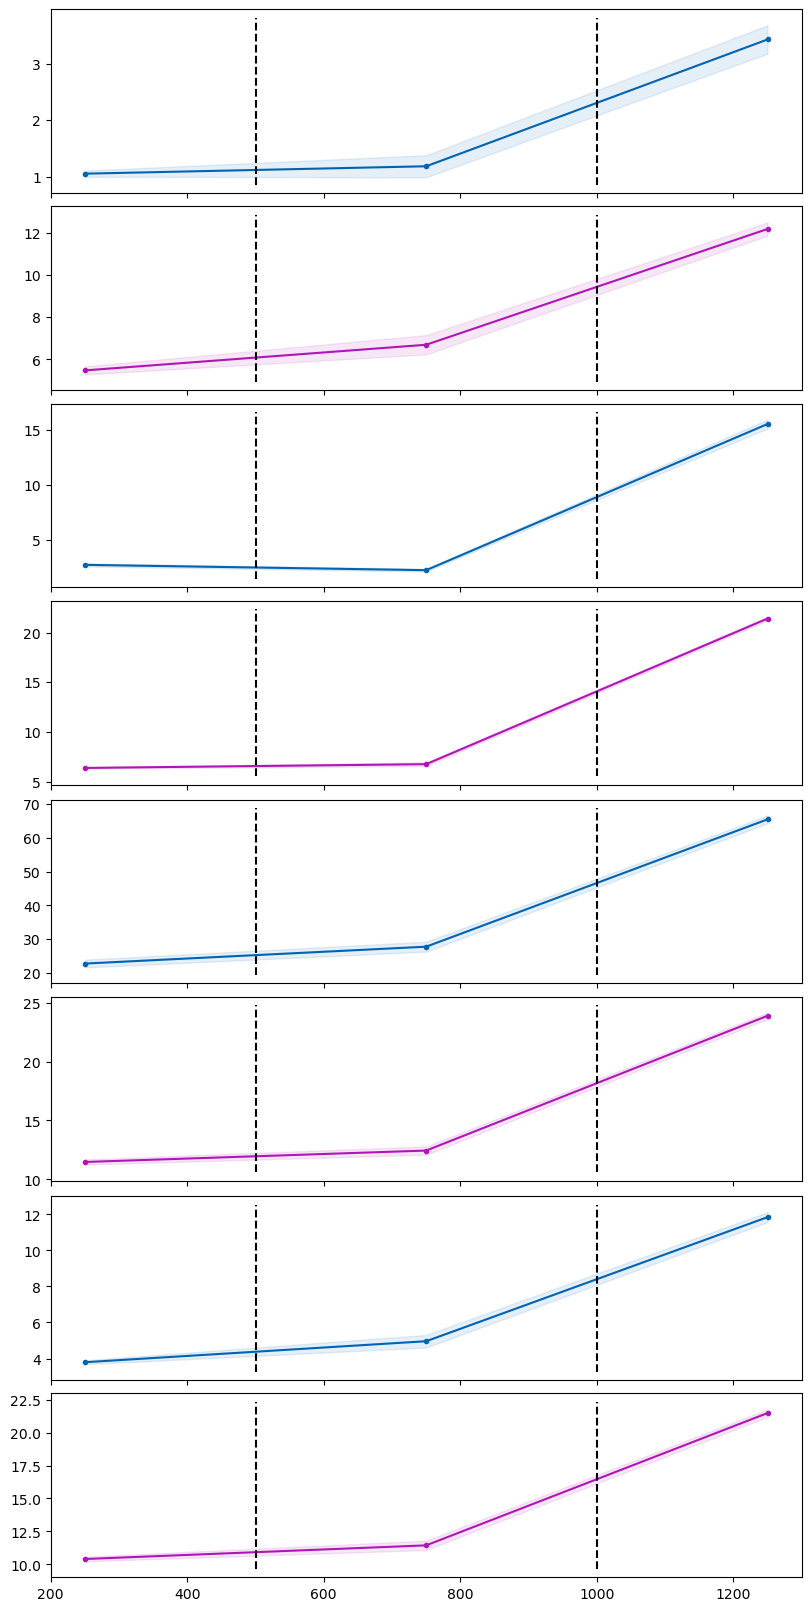

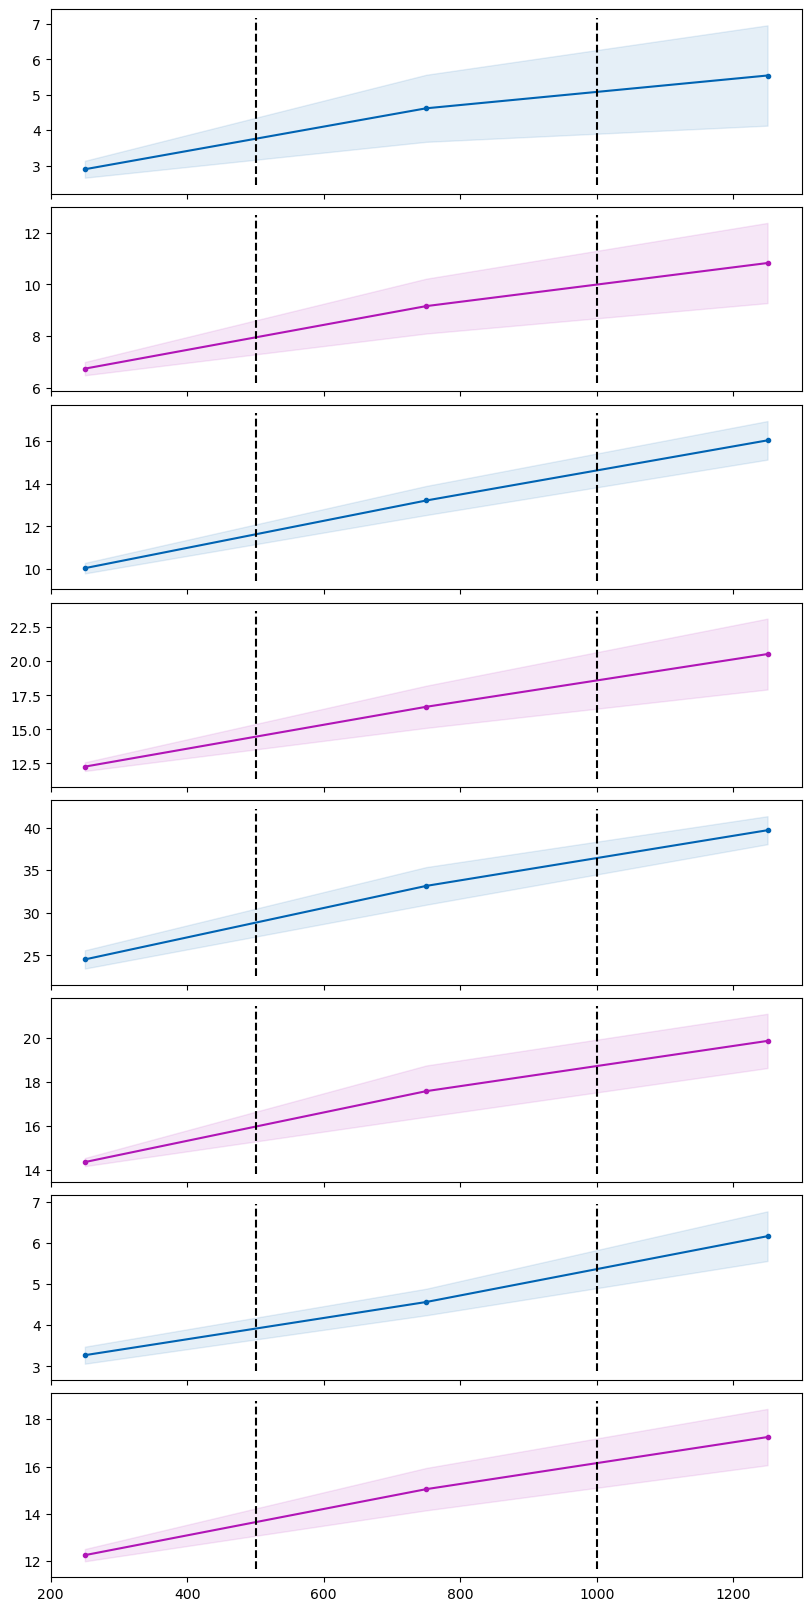

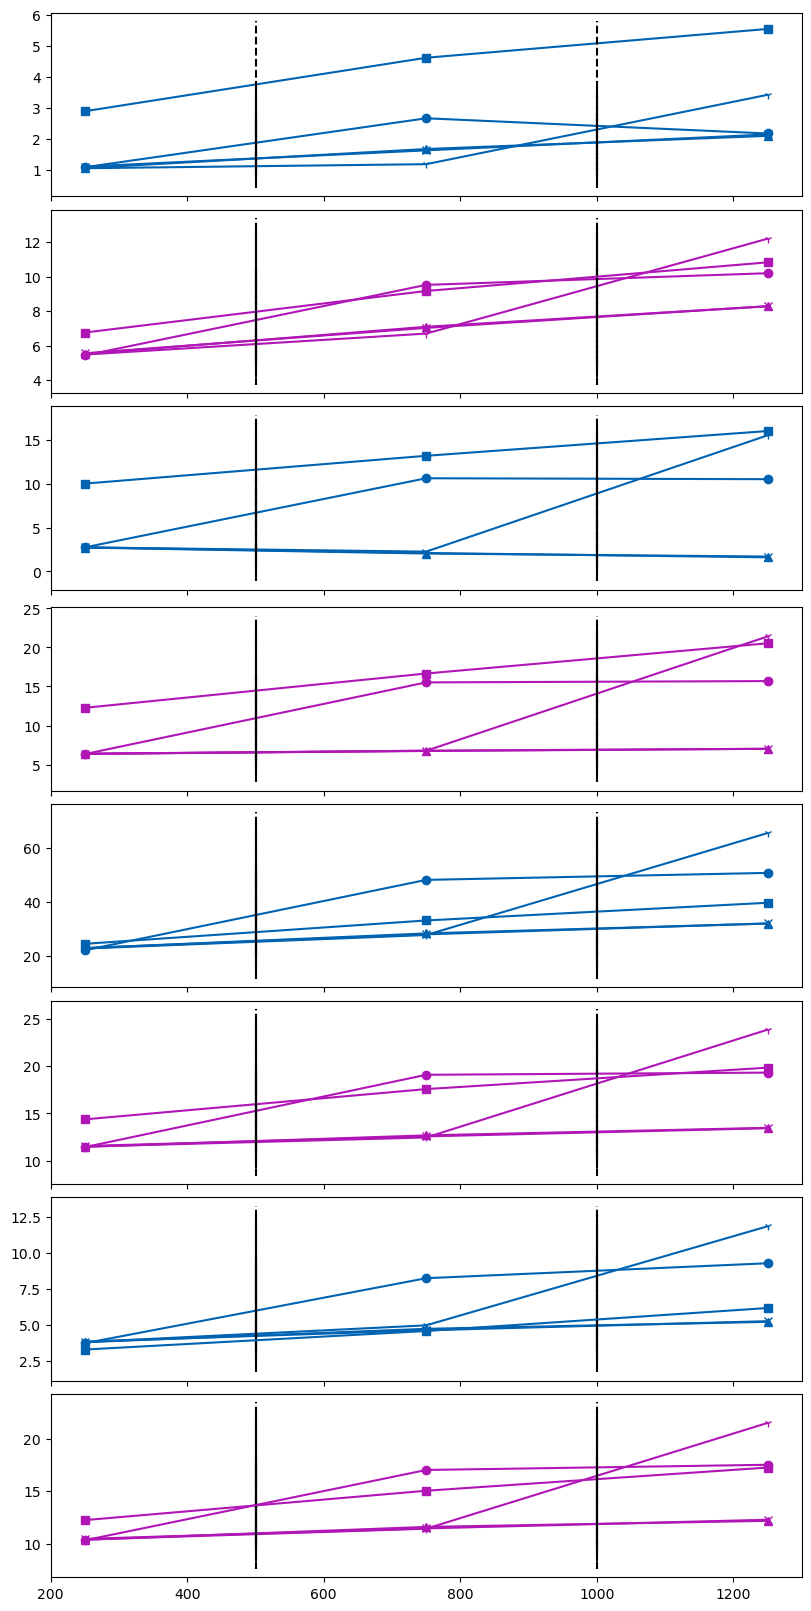

In [7]:
# PSTH nuevos
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')
#folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'

l_bin = 500

psth.PSTH_folders_data(folder_path, 0.1, 1500, l_bin) 

psth.PSTH_figure(folder_path, 1500, l_bin, 0)
psth.PSTH_figure(folder_path, 1500, l_bin, 2)
psth.PSTH_figure(folder_path, 1500, l_bin, 4)
psth.PSTH_plot_tog(folder_path, 1500, l_bin)

#psth.PSTH_plot(folder_path, 1600, l_bin)



In [274]:
# calculo cantidad de sinapsis

N_scaling, K_scaling = 0.1, 0.3

# internas
conn_probs = np.array(
        [
            [0.1009, 0.1689, 0.0437, 0.0818, 0.0323, 0.,     0.0076, 0.],       # L23E
            [0.1346, 0.1371, 0.0316, 0.0515, 0.0755, 0.,     0.0042, 0.],       # L23I
            [0.0077, 0.0059, 0.0497, 0.135,  0.0067, 0.0003, 0.0453, 0.],       # L4E
            [0.0691, 0.0029, 0.0794, 0.1597, 0.0033, 0.,     0.1057, 0.],       # L4I
            [0.1004, 0.0622, 0.0505, 0.0057, 0.0831, 0.3726, 0.0204, 0.],       # L5E
            [0.0548, 0.0269, 0.0257, 0.0022, 0.06,   0.3158, 0.0086, 0.],       # L5I
            [0.0156, 0.0066, 0.0211, 0.0166, 0.0572, 0.0197, 0.0396, 0.2252],   # L6E
            [0.0364, 0.001,  0.0034, 0.0005, 0.0277, 0.008,  0.0658, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )
full_num_neurons = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)
full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)

print(np.round(full_syn_sum/full_num_neurons))

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)


print(num_synapses.sum())
print('***********')
#print(num_synapses)
#print(num_synapses.sum(axis=1))
print(np.round(full_num_neurons * N_scaling).astype(int).sum())
print( np.round(num_synapses.sum(axis=1)/(full_num_neurons*N_scaling)).astype(int))

# talámicas
conn_probs_th = np.array([0.13, 0.075, 0.0, 0.0, 0.13, 0.075, 0.0, 0.0])
num_th_neurons = 902

prod = np.outer(num_th_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs_th) / np.log((prod - 1.) / prod)

num_synapses_th = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
print('***tal********')
#print(num_synapses_th)
print( num_synapses_th)


# lateral
conn_probs = np.array(
            [[0.12, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23E
             [0.03, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4E
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5E
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L6E
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])    # L6I
            # L2E  L2I  L4E  L4I  L5E  L5I  L6E  L6I}

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)
    
num_synapses_lat = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
print('*****Lat******')
#print(num_synapses_lat)
print( np.round(num_synapses_lat.sum(axis=1)/(full_num_neurons*N_scaling)).astype(int))


# feedforward
conn_probs = np.array(
            [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23E
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23I
             [0.005, 0.0, 0.0, 0.0, 0.005, 0.0, 0.005, 0.0],      # L4E
             [0.001, 0.0, 0.0, 0.0, 0.002, 0.0, 0.002, 0.0],      # L4I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5E
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5I
             [0.00, 0.0, 0.0, 0.0, 0.00, 0.0, 0.00, 0.0],      # L6E
             [0.00, 0.0, 0.0, 0.0, 0.00, 0.0, 0.00, 0.0]])
             
prod = np.outer(full_num_neurons, full_num_neurons_v2)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

num_synapses_ff = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
print('***********')
#print(num_synapses_lat)
print(num_synapses_ff)
print(902*0.2)
#print('***********')
#num_tot_syn = num_synapses.sum(axis=1)+num_synapses_th[0]+num_synapses_lat.sum(axis=1)
#print(num_tot_syn)

#num_neurons = np.round(full_num_neurons * N_scaling).astype(int)
#print(num_synapses_lat.sum(axis=1)/num_neurons)

print(np.array([0.0, 0.0, 0.0983, 0.0619, 0.0, 0.0, 0.0512, 0.0196])/3)

[4995. 5285. 2806. 5888. 4944. 2736. 2564. 2434.]
8966427
***********
7717
[1499 1585  842 1767 1483  821  769  730]
***tal********
[[77942 12308     0     0 18277  2247     0     0]]
*****Lat******
[793 189   0   0   0   0   0   0]
***********
[[    0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0]
 [64911     0     0     0 24512     0 24729     0]
 [ 3239     0     0     0  2448     0  2469     0]
 [    0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0]]
180.4
[0.         0.         0.03276667 0.02063333 0.         0.
 0.01706667 0.00653333]


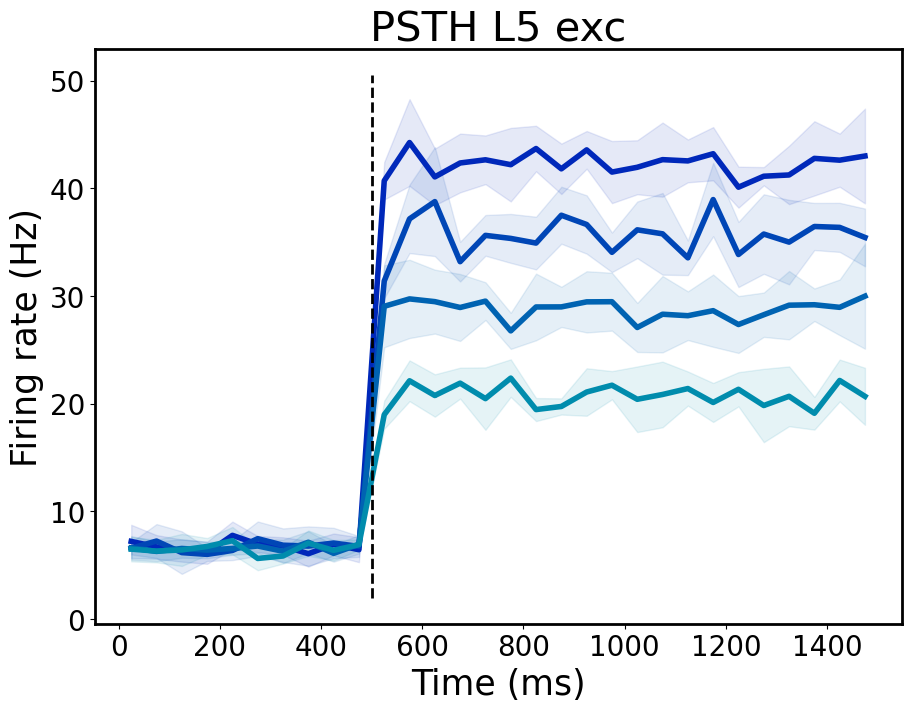

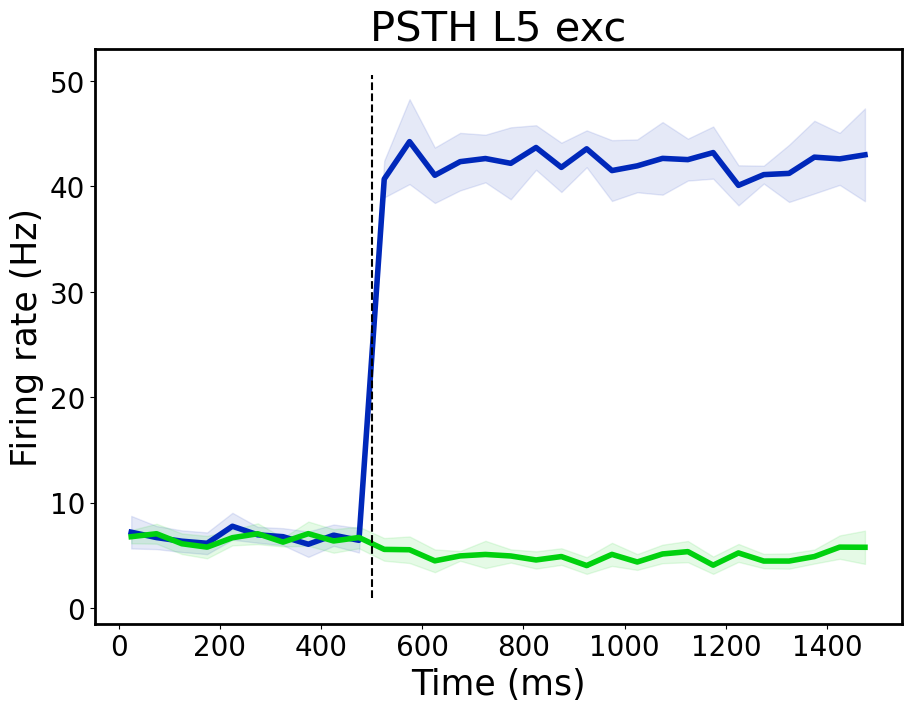

In [47]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result1_4'
t_sim = 1500
l_bin = 50

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))

#################

subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'] == '5a')][names[3:]].values

print()
fig, ax = plt.subplots(layout='constrained', figsize=(9,7), sharex=True)

color = ['#0028BA','#0046B6','#0063B2','#008CAD']
for i in range(0, len(subset),2):
 
    y = subset[i]
    ci = subset[i+1]

    ax.plot(bin_centers, y, '.-',lw=4, color=color[int(i/2)], markersize=2)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color=color[int(i/2)], alpha=.1)

bot, top = ax.get_ylim()  # return the current ylim
ax.plot([500, 500], [bot, top], 'k--', lw=2)

plt.xlabel('Time (ms)',fontsize=25)
plt.ylabel('Firing rate (Hz)',fontsize=25)
plt.title('PSTH L5 exc',fontsize=30)
plt.xticks(fontsize = 20) 
plt.yticks(fontsize = 20) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()

####################

subset = mean_data[names[3:]].values

fig, ax = plt.subplots(layout='constrained', figsize=(9,7), sharex=True)

color = ['#0028BA','#0046B6','#0063B2','#008CAD']

y = subset[8]
ci = subset[9]

ax.plot(bin_centers, y, '.-', lw=4, color='#0028BA', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#0028BA', alpha=.1)

y = subset[24]
ci = subset[25]

ax.plot(bin_centers, y, '.-',lw=4, color='#00D10E', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#00D10E', alpha=.1)

bot, top = ax.get_ylim()  # return the current ylim
ax.plot([500, 500], [bot, top], 'k--')

plt.xlabel('Time (ms)',fontsize=25)
plt.ylabel('Firing rate (Hz)',fontsize=25)
plt.title('PSTH L5 exc',fontsize=30)
plt.xticks(fontsize = 20) 
plt.yticks(fontsize = 20) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()

a
a
a
a


ValueError: Incorrect use of keyword argument 'xfontsize'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

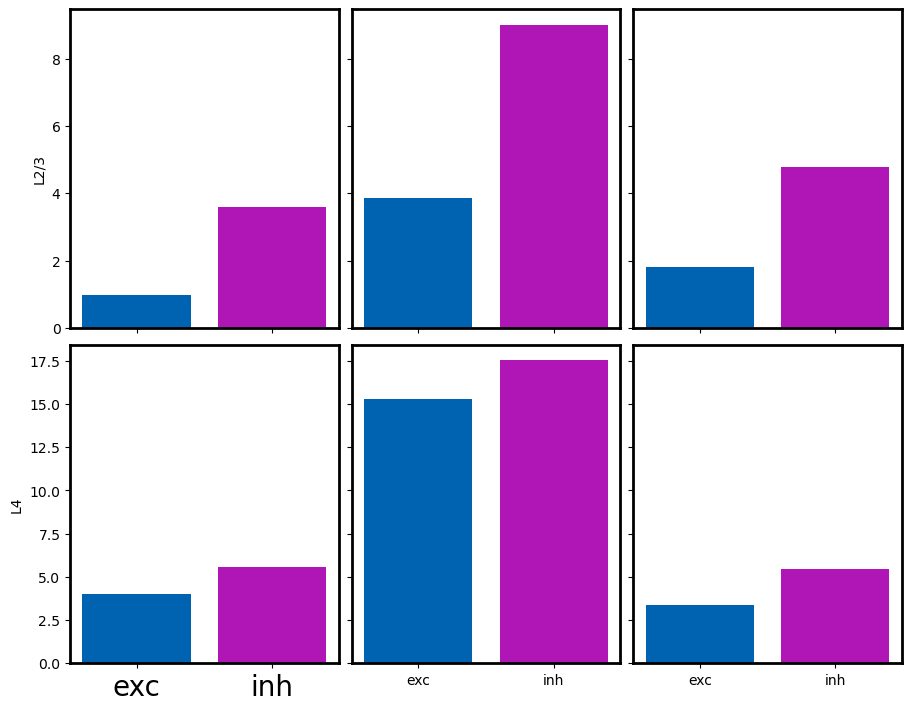

In [71]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result1_2'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(2,3,layout='constrained', figsize=(9,7), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']
for i,ii in enumerate([0,32]):
    for j,jj in enumerate(range(0,8,4)):
        if i==0:
            ax[j,i].bar(0, subset[ii+jj,0],color='#0063B2')
            ax[j,i].bar(1, subset[ii+jj+2,0],color='#b015b6')
            ax[j,i].set_ylabel(layer[j])
            for spine in ax[j,i].spines.values():
                spine.set_linewidth(2)
            try: 
                ax[j,i].set_xticks( fontsize=20)
            except:
                print('a')
            try: 
                ax[j,i].tick_params(labelsize=10)
            except:
                print('a')


        ax[j,i+1].bar(0, subset[ii+jj,1],color='#0063B2')
        ax[j,i+1].bar(1, subset[ii+jj+2,1],color='#b015b6')
        for spine in ax[j,i+1].spines.values():
                spine.set_linewidth(2) 

ax[1,0].set_xticks([0,1],['exc','inh'],fontsize = 20)
ax[1,0].set_yticks(ax[1,0].get_yticks(), xfontsize = 20)

##plt.xlabel('Time (ms)',fontsize=25)
#plt.ylabel('Firing rate (Hz)',fontsize=25)
#plt.title('PSTH L5 exc',fontsize=30)
#plt.xticks(fontsize = 20) 
#plt.yticks(fontsize = 20)

plt.show()

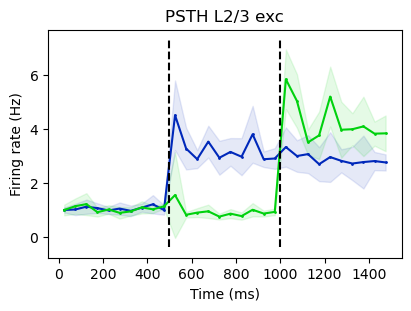

In [499]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result2_3'
t_sim = 1500
l_bin = 50

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))

#################

subset = mean_data[names[3:]].values

fig, ax = plt.subplots(layout='constrained', figsize=(4,3), sharex=True)

color = ['#0028BA','#0046B6','#0063B2','#008CAD']
 
y = subset[0]
ci = subset[1]

ax.plot(bin_centers, y, '.-', color='#0028BA', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#0028BA', alpha=.1)

y = subset[16]
ci = subset[17]

ax.plot(bin_centers, y, '.-', color='#00D10E', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#00D10E', alpha=.1)


bot, top = ax.get_ylim()  # return the current ylim
ax.plot([500, 500], [bot, top], 'k--')
ax.plot([1000, 1000], [bot, top], 'k--')

plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')
plt.title('PSTH L2/3 exc')
plt.show()



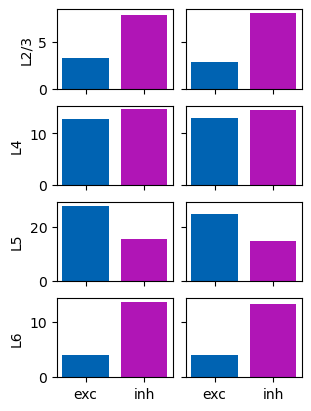

In [478]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result2_3'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(0,16,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
# plt.show()

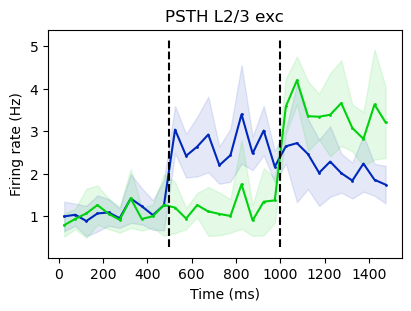

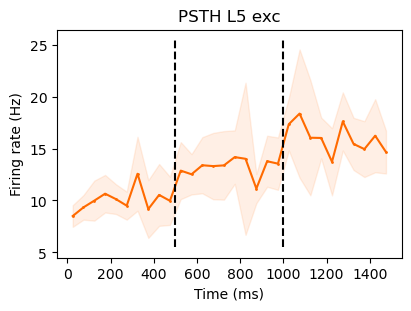

In [8]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_5'
t_sim = 1500
l_bin = 50

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))


#################

subset = mean_data[names[3:]].values

fig, ax = plt.subplots(layout='constrained', figsize=(4,3), sharex=True)
 
y = subset[0]
ci = subset[1]

ax.plot(bin_centers, y, '.-', color='#0028BA', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#0028BA', alpha=.1)

y = subset[16]
ci = subset[17]

ax.plot(bin_centers, y, '.-', color='#00D10E', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#00D10E', alpha=.1)

bot, top = ax.get_ylim()  # return the current ylim
ax.plot([500, 500], [bot, top], 'k--')
ax.plot([1000, 1000], [bot, top], 'k--')

plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')
plt.title('PSTH L2/3 exc')
plt.show()
#####


fig, ax = plt.subplots(layout='constrained', figsize=(4,3), sharex=True)
 
y = subset[36]
ci = subset[37]

ax.plot(bin_centers, y, '.-', color='#FF6A00', markersize=2)
ax.fill_between(bin_centers, (y-ci), (y+ci), color='#FF6A00', alpha=.1)

bot, top = ax.get_ylim()  # return the current ylim
ax.plot([500, 500], [bot, top], 'k--')
ax.plot([1000, 1000], [bot, top], 'k--')

plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')
plt.title('PSTH L5 exc')
plt.show()




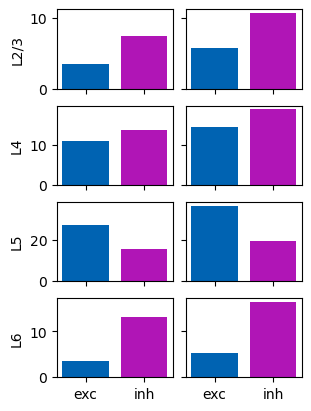

In [4]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(32,16+32,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
plt.show()

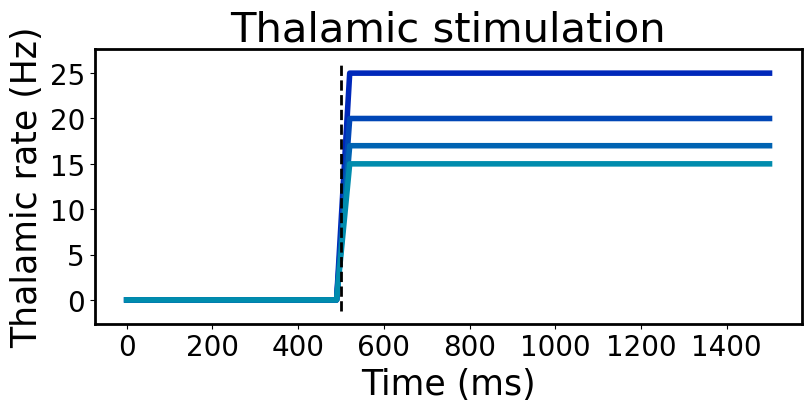

In [46]:
fig, ax = plt.subplots(layout='constrained', figsize=(8,4), sharex=True, sharey='row')

time = np.linspace(0,1500)

stim1, stim2, stim3, stim4 = [], [], [], []
for i in time:
    if i >= 500:
        stim1.append(25)
        stim2.append(20)
        stim3.append(17)
        stim4.append(15)
    else:
        stim1.append(0)
        stim2.append(0)
        stim3.append(0)
        stim4.append(0)


color = ['#0028BA','#0046B6','#0063B2','#008CAD']


ax.plot(time,stim1,lw=4,color=color[0])
ax.plot(time,stim2,lw=4,color=color[1])
ax.plot(time,stim3,lw=4,color=color[2])
ax.plot(time,stim4,lw=4,color=color[3])

bot, top = ax.get_ylim()  # return the current ylim

ax.plot([500, 500], [bot, top], 'k--', lw=2)

plt.xlabel('Time (ms)',fontsize=25)
plt.ylabel('Thalamic rate (Hz)',fontsize=25)
plt.title('Thalamic stimulation',fontsize=30)

plt.xticks(fontsize = 20) 
plt.yticks(fontsize = 20) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()